# House Prices — Advanced Regression Techniques

Real Kaggle competition data (see `data/house_prices/SOURCE.md`): 1460 training
rows, 81 columns, target `SalePrice`. This notebook demonstrates:

- A **full** `EDAAnalyzer` profile (missingness, skew, VIF/multicollinearity,
  target correlations, outliers, the decision-tree feature-importance
  surrogate, automated recommendations) plus `EDAVisualizer` and
  `expect_*` data-quality gates.
- Deep, domain-informed feature engineering (NA-semantic recoding, ratio/age
  features) done *before* the split (deterministic, no leakage) — followed by
  learned preprocessing (imputation, encoding, scaling, correlation-based
  feature selection) done *after* the split, inside a leakage-safe
  `SkyulfPipeline`.
- Hyperparameter tuning via the pipeline's built-in `hyperparameter_tuner`
  wrapper, compared against an untuned baseline and a tree-based model.

Polars + numpy only — no pandas.

In [1]:
import numpy as np
import polars as pl

from skyulf import SkyulfPipeline
from skyulf.profiling.analyzer import EDAAnalyzer
from skyulf.profiling.expect import ExpectationError, expect_no_nulls, expect_value_range
from skyulf.profiling.visualizer import EDAVisualizer

pl.Config.set_tbl_cols(15)

train = pl.read_csv("data/house_prices/train.csv", null_values=["NA"], infer_schema_length=None)
print(train.shape)
train.head()

(1460, 81)


Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,…,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
i64,i64,str,i64,i64,str,str,…,str,i64,i64,i64,str,str,i64
1,60,"""RL""",65,8450,"""Pave""",null,…,null,0,2,2008,"""WD""","""Normal""",208500
2,20,"""RL""",80,9600,"""Pave""",null,…,null,0,5,2007,"""WD""","""Normal""",181500
3,60,"""RL""",68,11250,"""Pave""",null,…,null,0,9,2008,"""WD""","""Normal""",223500
4,70,"""RL""",60,9550,"""Pave""",null,…,null,0,2,2006,"""WD""","""Abnorml""",140000
5,60,"""RL""",84,14260,"""Pave""",null,…,null,0,12,2008,"""WD""","""Normal""",250000


## 1. Full EDA before any feature engineering

`EDAAnalyzer.analyze(target_col="SalePrice")` runs the complete profile in
one call. We read every part of it, not just a summary print — alerts,
recommendations, VIF, target correlations/interactions, outliers, and the
decision-tree feature-importance surrogate.

In [2]:
profile = EDAAnalyzer(train).analyze(target_col="SalePrice")

print(f"Rows: {profile.row_count}  Columns: {profile.column_count}")
print(f"Duplicate rows: {profile.duplicate_rows}")
print(f"Missing cells: {profile.missing_cells_percentage:.2f}%")
print(f"Alerts ({len(profile.alerts)}):")
for a in profile.alerts[:10]:
    print(f"  [{a.severity}] {a.column}: {a.message}")

calculate_correlations: 37 numeric columns exceeds the 20-column cap; truncating to the first 20 by column order (not variance or relevance) and dropping ['HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'] from the correlation matrix.


calculate_correlations: 38 numeric columns exceeds the 20-column cap; truncating to the first 20 by column order (not variance or relevance) and dropping ['HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice'] from the correlation matrix.


Error in causal discovery: Data correlation matrix is singular. Cannot run fisherz test. Please check your data.


Rows: 1460  Columns: 81
Duplicate rows: 0
Missing cells: 5.89%
Alerts (31):
  [info] Id: Column 'Id' appears to be an ID.
  [warning] LotFrontage: Column 'LotFrontage' has 17.7% missing values.
  [info] LotFrontage: Column 'LotFrontage' contains significant outliers.
  [info] LotArea: Column 'LotArea' contains significant outliers.
  [warning] Alley: Column 'Alley' has 93.8% missing values.
  [info] YearBuilt: Column 'YearBuilt' contains significant outliers.
  [info] MasVnrArea: Column 'MasVnrArea' contains significant outliers.
  [info] BsmtFinSF1: Column 'BsmtFinSF1' contains significant outliers.
  [info] BsmtUnfSF: Column 'BsmtUnfSF' contains significant outliers.
  [info] TotalBsmtSF: Column 'TotalBsmtSF' contains significant outliers.


In [3]:
print(f"Recommendations ({len(profile.recommendations)}):")
for r in profile.recommendations[:10]:
    print(f"  {r.action} -> {r.column}: {r.reason}")

Recommendations (34):
  Impute -> LotFrontage: Missing values (17.7%)
  Drop -> Alley: High missing values (93.8%)
  Impute -> MasVnrType: Missing values (0.5%)
  Impute -> MasVnrArea: Missing values (0.5%)
  Impute -> BsmtQual: Missing values (2.5%)
  Impute -> BsmtCond: Missing values (2.5%)
  Impute -> BsmtExposure: Missing values (2.6%)
  Impute -> BsmtFinType1: Missing values (2.5%)
  Impute -> BsmtFinType2: Missing values (2.6%)
  Impute -> Electrical: Missing values (0.1%)


In [4]:
# Multicollinearity: any feature pair with VIF > 5 is a candidate for the
# correlation-based feature selection step in the pipeline below.
high_vif = {c: v for c, v in profile.vif.items() if v and v > 5}
print(f"{len(high_vif)} numeric columns with VIF > 5:")
for c, v in sorted(high_vif.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {c}: {v:.1f}")

5 numeric columns with VIF > 5:
  BsmtFinSF1: 261503685489483.1
  BsmtUnfSF: 241590792569455.8
  TotalBsmtSF: 236717478403721.2
  BsmtFinSF2: 29688141264691.2
  YearBuilt: 6.1


In [5]:
# Target correlations (numeric target -> Pearson) and target interactions
# (categorical -> boxplot + ANOVA p-value) are exactly the "why does this
# feature matter" answer a newcomer usually hand-rolls themselves.
top_corr = sorted(profile.target_correlations.items(), key=lambda kv: -abs(kv[1]))[:10]
print("Strongest linear correlations with SalePrice:")
for c, v in top_corr:
    print(f"  {c}: {v:+.3f}")

if profile.rule_tree is not None and profile.rule_tree.feature_importances:
    print(f"\nDecision-tree surrogate R^2: {profile.rule_tree.accuracy:.3f}")
    top_importance = sorted(
        profile.rule_tree.feature_importances, key=lambda d: -d["importance"]
    )[:10]
    print("Feature importances (surrogate):")
    for d in top_importance:
        print(f"  {d['feature']}: {d['importance']:.3f}")

Strongest linear correlations with SalePrice:
  OverallQual: +0.791
  GrLivArea: +0.709
  GarageCars: +0.640
  GarageArea: +0.623
  TotalBsmtSF: +0.614
  1stFlrSF: +0.606
  FullBath: +0.561
  TotRmsAbvGrd: +0.534
  YearBuilt: +0.523
  YearRemodAdd: +0.507

Decision-tree surrogate R^2: 0.778
Feature importances (surrogate):
  GarageCars: 0.469
  GrLivArea: 0.254
  TotalBsmtSF: 0.077
  BsmtFinSF1: 0.062
  YearRemodAdd: 0.033
  2ndFlrSF: 0.025
  YearBuilt: 0.021
  HalfBath: 0.020
  1stFlrSF: 0.017
  OverallQual: 0.012


In [6]:
EDAVisualizer(profile, train).summary()

╭────────────────────╮
│ Skyulf EDA Summary │
╰────────────────────╯

1. Data Quality

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Metric         ┃ Value              ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Rows           │ 1460               │
│ Columns        │ 81                 │
│ Missing Cells  │ 5.889565364451209% │
│ Duplicate Rows │ 0                  │
│ Target Column  │ SalePrice          │
│ Task Type      │ Regression         │
└────────────────┴────────────────────┘

2. Numeric Statistics

┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┓
┃ Column        ┃      Mean ┃      Std ┃      Min ┃       Max ┃  Skew ┃   Kurt ┃ Normality ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━┩
│ Id            │    730.50 │   421.61 │     1.00 │   1460.00 │  0.00 │  -1.20 │    No     │
│ LotFrontage   │     70.05 │    24.28 │    21.00 │    313.00 │  2.16 │  17.38 │    No     │
│ LotArea       │  10516.83 │  9981.26 │  1300.00 │ 215245.00 │ 12.20 │ 202.54 │    No     │
│ YearBuilt     │   1971.27 │    30.20 │  1872.00 │   2010.00 │ -0.61 │  -0.44 │    No     │
│ YearRemodAdd  │   1984.87 │    20.65 │  1950.00 │   2010.00 │ -0.50 │  -1.27 │    No     │
│ MasVnrArea    │    103.69 │   181.07 │     0.00 │   1600.00 │  2.67 │  10.04 │    No     │
│ BsmtFinSF1    │    443.64 │   456.10 │     0.00 │   5644.00 │  1.68 │  11.08 │    No     │
│ BsmtFinSF2    │     46.55 │   161.32 │     0.00 │   1474.00 │  4.25 │  20.04 │    No     │
│ BsmtUnfSF     │    567.24 │   441.87 │     0.00 │   2336.00 │  0.92 │   0.47 │    No     │
│ TotalBsmtSF   │   1057.43 │   438.71 │     0.00 │   6110.00 │  1.52 │  13.20 │    No     │
│ 1stFlrSF      │   1162.63 │   386.59 │   334.00 │   4692.00 │  1.38 │   5.72 │    No     │
│ 2ndFlrSF      │    346.99 │   436.53 │     0.00 │   2065.00 │  0.81 │  -0.56 │    No     │
│ LowQualFinSF  │      5.84 │    48.62 │     0.00 │    572.00 │  9.00 │  82.95 │    No     │
│ GrLivArea     │   1515.46 │   525.48 │   334.00 │   5642.00 │  1.37 │   4.87 │    No     │
│ GarageYrBlt   │   1978.51 │    24.69 │  1900.00 │   2010.00 │ -0.65 │  -0.42 │    No     │
│ GarageArea    │    472.98 │   213.80 │     0.00 │   1418.00 │  0.18 │   0.91 │    No     │
│ WoodDeckSF    │     94.24 │   125.34 │     0.00 │    857.00 │  1.54 │   2.98 │    No     │
│ OpenPorchSF   │     46.66 │    66.26 │     0.00 │    547.00 │  2.36 │   8.46 │    No     │
│ EnclosedPorch │     21.95 │    61.12 │     0.00 │    552.00 │  3.09 │  10.39 │    No     │
│ 3SsnPorch     │      3.41 │    29.32 │     0.00 │    508.00 │ 10.29 │ 123.24 │    No     │
│ ScreenPorch   │     15.06 │    55.76 │     0.00 │    480.00 │  4.12 │  18.37 │    No     │
│ MiscVal       │     43.49 │   496.12 │     0.00 │  15500.00 │ 24.45 │ 698.60 │    No     │
│ SalePrice     │ 180921.20 │ 79442.50 │ 34900.00 │ 755000.00 │  1.88 │   6.51 │    No     │
└───────────────┴───────────┴──────────┴──────────┴───────────┴───────┴────────┴───────────┘

...

• Column 'YearBuilt' has high VIF (6.1).

• Column 'BsmtFinSF1' has very high VIF (261503685489483.1). Consider removing it.

• Column 'BsmtFinSF2' has very high VIF (29688141264691.2). Consider removing it.

• Column 'BsmtUnfSF' has very high VIF (241590792569455.8). Consider removing it.

• Column 'TotalBsmtSF' has very high VIF (236717478403721.2). Consider removing it.

Displaying plots...


/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


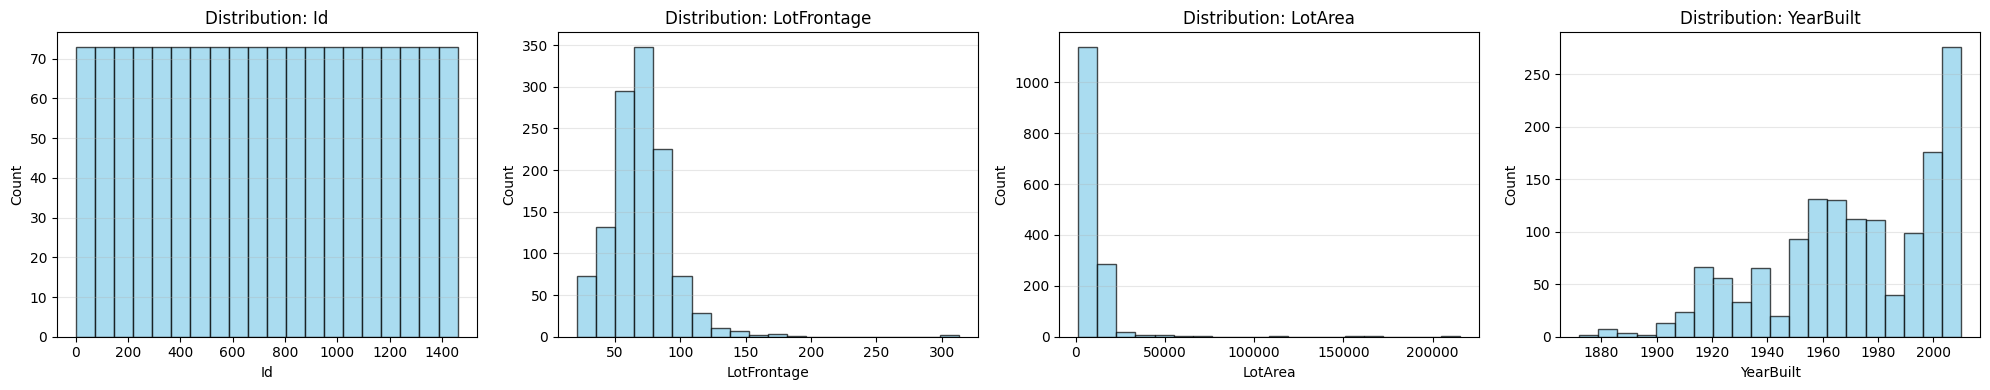

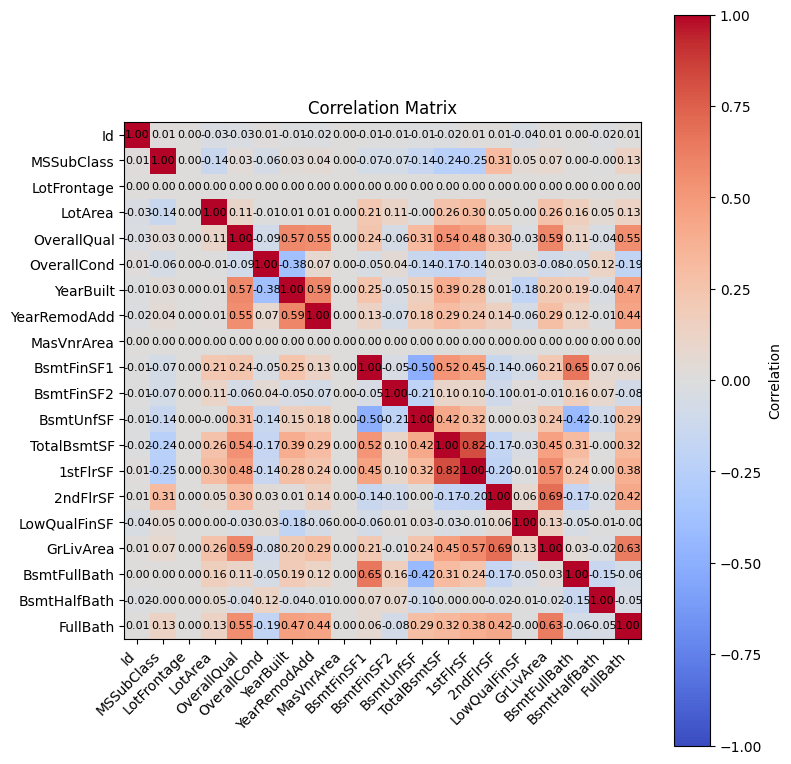

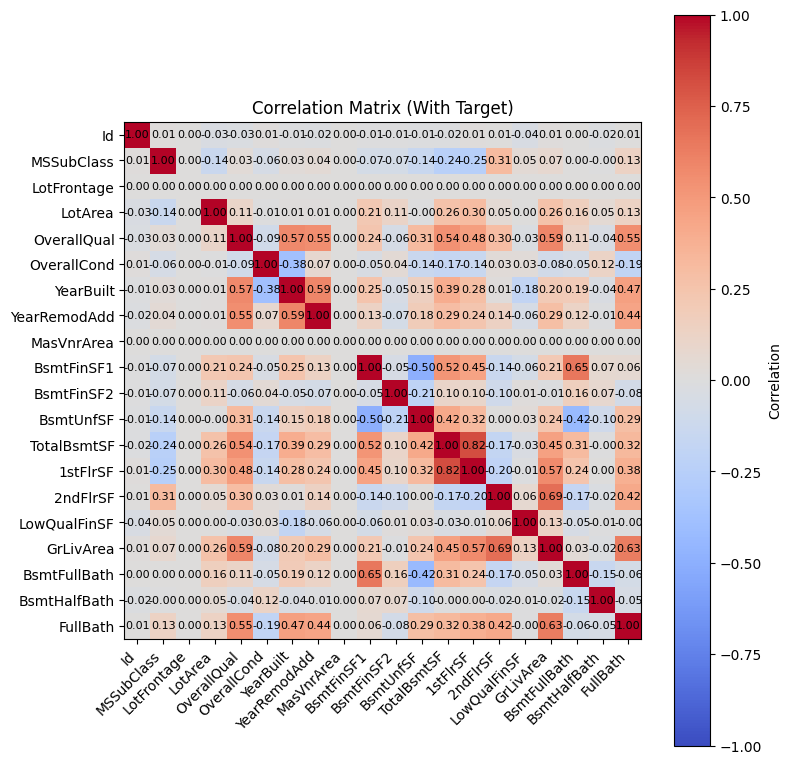

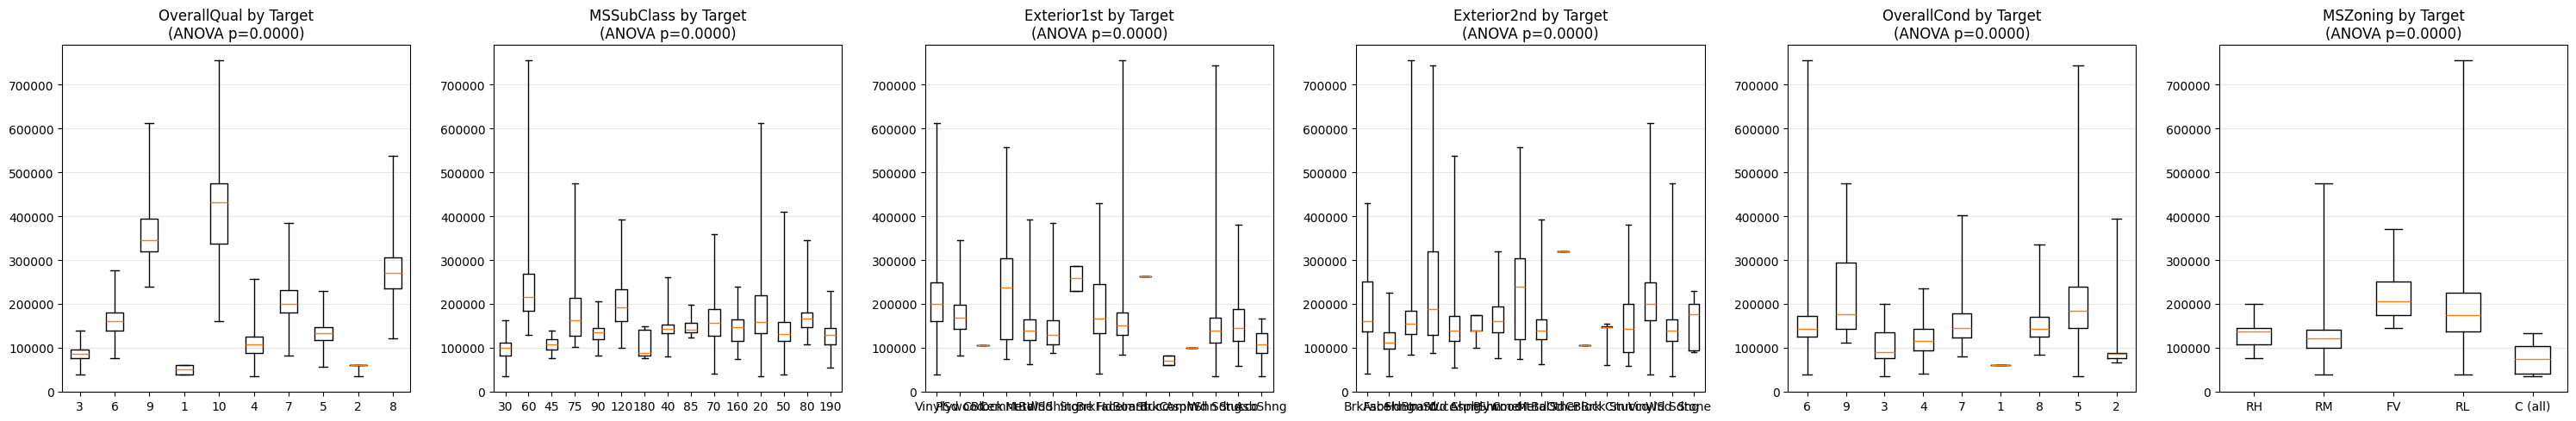

<Figure size 1000x1000 with 0 Axes>

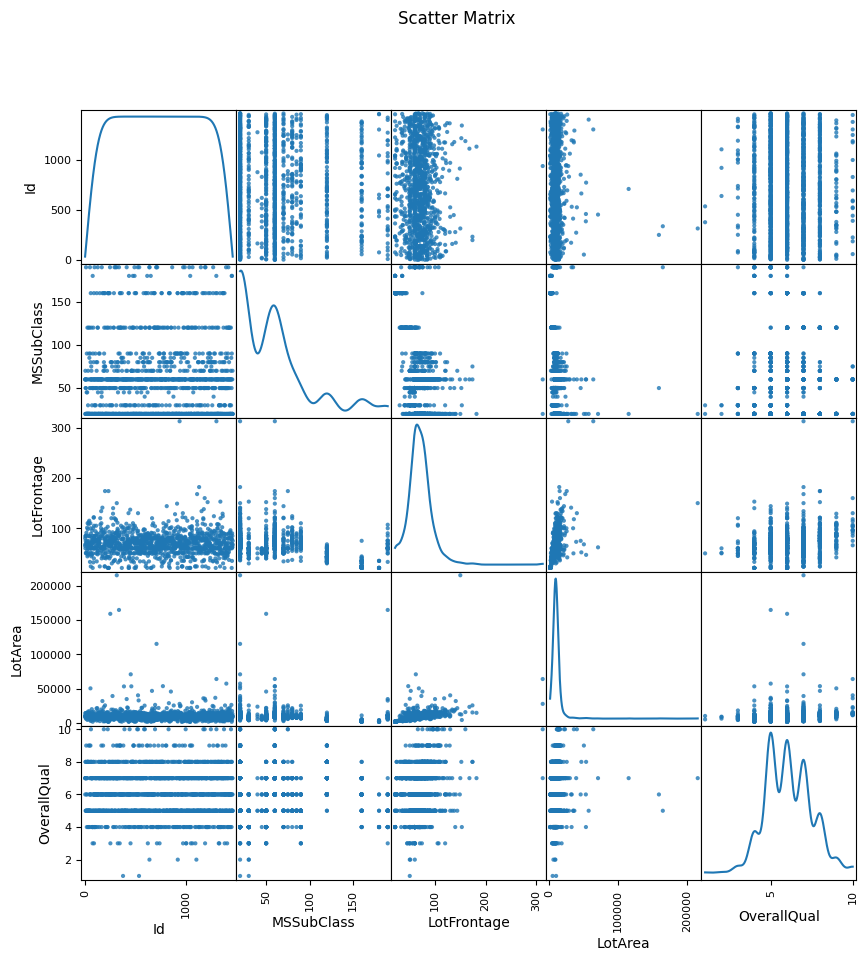

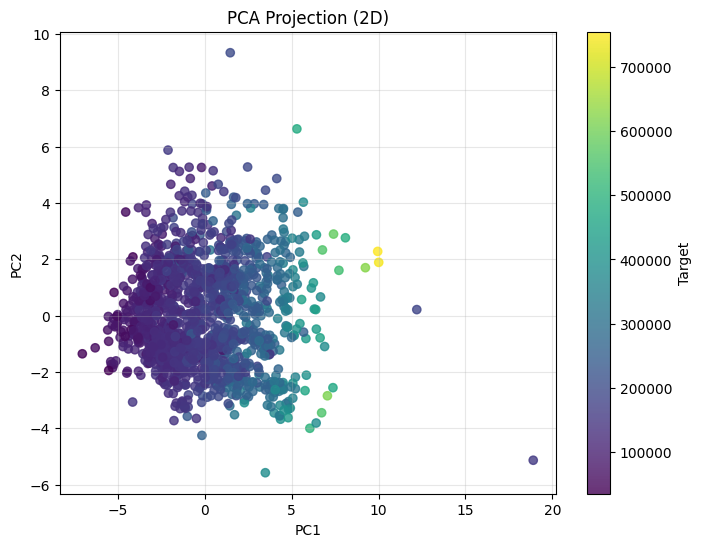

In [7]:
EDAVisualizer(profile, train).plot()

## 2. Data-quality gates with `expect_*`

Before we engineer features, a couple of lightweight sanity checks —
these are the kind of guard you'd keep in a production pipeline.

In [8]:
try:
    expect_no_nulls(train, ["SalePrice", "Id"])
    expect_value_range(train, "SalePrice", minimum=0)
    print("Data-quality gates passed.")
except ExpectationError as e:
    print("Data-quality gate failed:", e)

Data-quality gates passed.


## 3. Deep feature engineering (deterministic, pre-split)

Everything in this section is **domain knowledge applied deterministically**
(no statistic learned from the data), so it's safe to do before the
train/test split: NA-semantic recoding (many "NA"s in this dataset mean
"does not have this feature", not "unknown"), ordinal quality mappings, and
ratio/age features. Anything that *learns* from the data (imputing genuinely
unknown values, scaling, encoding nominal categories) happens **after** the
split, inside the pipeline.

In [9]:
QUALITY_MAP = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, None: 0}


def map_quality(col: str) -> pl.Expr:
    return pl.col(col).map_elements(lambda v: QUALITY_MAP.get(v, 0), return_dtype=pl.Int64).alias(col)


NONE_SEMANTIC_CATEGORICAL = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType",
    "GarageFinish", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "MasVnrType",
]
QUALITY_COLUMNS = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu"]


def engineer_features(df: pl.DataFrame) -> pl.DataFrame:
    df = df.with_columns(
        [pl.col(c).fill_null("None") for c in NONE_SEMANTIC_CATEGORICAL if c in df.columns]
    )
    # A handful of numeric columns have 0 nulls in train but 1-2 nulls in the
    # real Kaggle test.csv (e.g. a test-only house with no garage/basement
    # data recorded) -- fill_null(0) is the same deterministic "doesn't have
    # this feature" semantic used above, just applied to numeric columns, so
    # it's safe pre-split and keeps train/test feature engineering identical.
    ZERO_SEMANTIC_NUMERIC = [
        "GarageYrBlt", "MasVnrArea", "GarageArea", "GarageCars",
        "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    ]
    df = df.with_columns(
        [pl.col(c).fill_null(0) for c in ZERO_SEMANTIC_NUMERIC if c in df.columns]
    )
    # A few nominal categoricals are also only null in test.csv, never in
    # train.csv -- fill with an explicit "Unknown" category (deterministic,
    # no leakage) rather than letting a real missing value hit the encoder.
    UNKNOWN_SEMANTIC_CATEGORICAL = ["MSZoning", "Functional", "Utilities", "SaleType", "KitchenQual", "Exterior1st", "Exterior2nd"]
    df = df.with_columns(
        [pl.col(c).fill_null("Unknown") for c in UNKNOWN_SEMANTIC_CATEGORICAL if c in df.columns]
    )
    df = df.with_columns([map_quality(c) for c in QUALITY_COLUMNS])
    df = df.with_columns(
        [
            (pl.col("TotalBsmtSF") + pl.col("1stFlrSF") + pl.col("2ndFlrSF")).alias("TotalSF"),
            (pl.col("YrSold") - pl.col("YearBuilt")).alias("HouseAge"),
            (pl.col("YrSold") - pl.col("YearRemodAdd")).alias("RemodAge"),
            (
                pl.col("FullBath")
                + 0.5 * pl.col("HalfBath")
                + pl.col("BsmtFullBath")
                + 0.5 * pl.col("BsmtHalfBath")
            ).alias("TotalBath"),
            (pl.col("PoolArea") > 0).cast(pl.Int8).alias("HasPool"),
            (pl.col("GarageArea") > 0).cast(pl.Int8).alias("HasGarage"),
            (pl.col("2ndFlrSF") > 0).cast(pl.Int8).alias("Has2ndFloor"),
            (pl.col("Fireplaces") > 0).cast(pl.Int8).alias("HasFireplace"),
            (pl.col("SalePrice").log1p().alias("SalePrice_log")
             if "SalePrice" in df.columns else pl.lit(None).alias("SalePrice_log")),
        ]
    )
    return df


train_fe = engineer_features(train)
train_fe.select(["TotalSF", "HouseAge", "RemodAge", "TotalBath", "HasPool", "HasGarage", "SalePrice_log"]).head()

TotalSF,HouseAge,RemodAge,TotalBath,HasPool,HasGarage,SalePrice_log
i64,i64,i64,f64,i8,i8,f64
2566,5,5,3.5,0,1,12.247699
2524,31,31,2.5,0,1,12.109016
2706,7,6,3.5,0,1,12.317171
2473,91,36,2.0,0,1,11.849405
3343,8,8,3.5,0,1,12.42922


## 4. Curated feature set + leakage-safe pipeline

We select a curated ~30-column subset (numeric + a handful of informative
nominal categoricals) rather than all 81 raw columns, for notebook clarity —
the full column set is a natural "what to try next." `TrainTestSplitter` is
first, so imputation/encoding/scaling/feature-selection all fit on the
training split only.

In [10]:
NUMERIC_FEATURES = [
    "OverallQual", "OverallCond", "GrLivArea", "TotalSF", "HouseAge", "RemodAge",
    "TotalBath", "GarageArea", "GarageCars", "LotArea", "LotFrontage",
    "1stFlrSF", "TotBsmtSF" if "TotBsmtSF" in train_fe.columns else "TotalBsmtSF",
    "BedroomAbvGr", "TotRmsAbvGrd", "Fireplaces", "MasVnrArea",
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu",
    "HasPool", "HasGarage", "Has2ndFloor", "HasFireplace",
]
NOMINAL_FEATURES = ["Neighborhood", "MSZoning", "HouseStyle", "Foundation", "GarageType", "SaleCondition"]
FEATURES = [c for c in NUMERIC_FEATURES if c in train_fe.columns] + NOMINAL_FEATURES
TARGET = "SalePrice_log"

model_df = train_fe.select(FEATURES + [TARGET])
print(f"Final feature count: {len(FEATURES)}")
model_df.null_count().sum_horizontal()

Final feature count: 34


sum
u32
259


In [11]:
numeric_for_scaling = [c for c in NUMERIC_FEATURES if c in train_fe.columns]

base_preprocessing = [
    {
        "name": "split",
        "transformer": "TrainTestSplitter",
        "params": {"target_column": TARGET, "test_size": 0.2, "random_state": 42},
    },
    {
        "name": "impute_numeric",
        "transformer": "SimpleImputer",
        "params": {"columns": ["LotFrontage"], "strategy": "median"},
    },
    {
        "name": "encode_nominal",
        "transformer": "OneHotEncoder",
        "params": {"columns": NOMINAL_FEATURES, "drop_original": True, "handle_unknown": "ignore"},
    },
    {
        "name": "scale_numeric",
        "transformer": "StandardScaler",
        "params": {"columns": numeric_for_scaling},
    },
    {
        "name": "drop_redundant",
        "transformer": "CorrelationThreshold",
        "params": {"threshold": 0.95},
    },
]

## 5. Baseline: untuned Ridge regression

In [12]:
def summarize(name, metrics):
    m = metrics["modeling"]
    report = m["splits"]["test"] if "splits" in m else m.get("test", m)
    metrics_dict = report.metrics if hasattr(report, "metrics") else report
    r2 = metrics_dict.get("r2")
    rmse_log = metrics_dict.get("rmse")
    # RMSE was computed in log1p(SalePrice) space. `expm1(rmse_log) * 100` is
    # the standard way to read a log-space RMSE as an approximate *relative*
    # (percentage) price error -- it is NOT a dollar amount, so we don't try
    # to report one here.
    approx_pct_error = float(np.expm1(rmse_log)) * 100 if rmse_log is not None else None
    print(f"{name:28s} R2={r2:.4f}  RMSE(log)={rmse_log:.4f}  approx price error={approx_pct_error:.1f}%")
    return {"r2": r2, "rmse_log": rmse_log, "approx_pct_error": approx_pct_error}


baseline_config = {
    "preprocessing": base_preprocessing,
    "modeling": {"type": "ridge_regression", "params": {"alpha": 1.0, "random_state": 42}},
}

baseline_pipeline = SkyulfPipeline(baseline_config)
baseline_metrics = baseline_pipeline.fit(model_df, target_column=TARGET)
baseline_summary = summarize("Baseline Ridge", baseline_metrics)

Baseline Ridge               R2=0.9015  RMSE(log)=0.1356  approx price error=14.5%


## 6. Outlier handling — comparing strategies

The Ames Housing dataset's documentation famously recommends removing a
handful of extreme `GrLivArea` outliers (very large homes sold for
surprisingly low prices — data-entry quirks, not genuine market signal).
`skyulf` ships several outlier-handling nodes with different philosophies:
`Winsorize` clips extreme values to a percentile range (keeps every row),
while `IQR` removes whole outlier *rows*. We insert each right after the
split (before imputation/encoding/scaling) and compare against the
untuned Ridge baseline above (no outlier handling), on the exact same
model, to isolate the effect of outlier handling alone.

In [13]:
def insert_outlier_step(step: dict) -> list[dict]:
    """Insert an outlier-handling step right after the split, before imputation."""
    return [base_preprocessing[0], step] + base_preprocessing[1:]


outlier_cols = ["GrLivArea", "LotArea", "TotalSF"]

winsorize_config = {
    "preprocessing": insert_outlier_step(
        {"name": "winsorize", "transformer": "Winsorize",
         "params": {"columns": outlier_cols, "lower_percentile": 1.0, "upper_percentile": 99.0}}
    ),
    "modeling": {"type": "ridge_regression", "params": {"alpha": 1.0, "random_state": 42}},
}
iqr_config = {
    "preprocessing": insert_outlier_step(
        {"name": "iqr", "transformer": "IQR", "params": {"columns": outlier_cols, "multiplier": 3.0}}
    ),
    "modeling": {"type": "ridge_regression", "params": {"alpha": 1.0, "random_state": 42}},
}

winsorize_pipeline = SkyulfPipeline(winsorize_config)
winsorize_metrics = winsorize_pipeline.fit(model_df, target_column=TARGET)
winsorize_summary = summarize("Ridge + Winsorize", winsorize_metrics)

iqr_pipeline = SkyulfPipeline(iqr_config)
iqr_metrics = iqr_pipeline.fit(model_df, target_column=TARGET)
iqr_summary = summarize("Ridge + IQR row-removal", iqr_metrics)

outlier_results = {"No outlier handling": baseline_summary, "Winsorize": winsorize_summary, "IQR row-removal": iqr_summary}
best_outlier_strategy = min(outlier_results, key=lambda k: outlier_results[k]["rmse_log"])
print(f"\nBest outlier strategy on this split: {best_outlier_strategy} "
      f"(RMSE(log)={outlier_results[best_outlier_strategy]['rmse_log']:.4f})")

Ridge + Winsorize            R2=0.9088  RMSE(log)=0.1305  approx price error=13.9%
Ridge + IQR row-removal      R2=0.9191  RMSE(log)=0.1208  approx price error=12.8%

Best outlier strategy on this split: IQR row-removal (RMSE(log)=0.1208)


## 7. Tuned Ridge regression

The same preprocessing, but the modeling step is wrapped in the pipeline's
built-in `hyperparameter_tuner` (random search over `alpha`, 5-fold CV).

In [14]:
tuned_config = {
    "preprocessing": base_preprocessing,
    "modeling": {
        "type": "hyperparameter_tuner",
        "base_model": {"type": "ridge_regression"},
        "strategy": "random",
        "metric": "neg_root_mean_squared_error",
        "n_trials": 20,
        "cv_folds": 5,
        "cv_type": "k_fold",
        "search_space": {"alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]},
        "random_state": 42,
    },
}

tuned_pipeline = SkyulfPipeline(tuned_config)
tuned_metrics = tuned_pipeline.fit(model_df, target_column=TARGET)
tuned_summary = summarize("Tuned Ridge (random search)", tuned_metrics)

Tuned Ridge (random search)  R2=0.8988  RMSE(log)=0.1374  approx price error=14.7%


/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


## 8. A tree-based comparison: Optuna-tuned Gradient Boosting

Random search is fine for a single hyperparameter (`alpha`), but Gradient
Boosting has several interacting hyperparameters (`n_estimators`,
`max_depth`, `learning_rate`) — a good showcase for the pipeline's
**Optuna** tuning strategy (Bayesian/TPE search), not just grid/random.

In [15]:
gbr_config = {
    "preprocessing": base_preprocessing,
    "modeling": {
        "type": "hyperparameter_tuner",
        "base_model": {"type": "gradient_boosting_regressor"},
        "strategy": "optuna",
        "metric": "neg_root_mean_squared_error",
        "n_trials": 25,
        "cv_folds": 5,
        "cv_type": "k_fold",
        "search_space": {
            "n_estimators": [100, 200, 300, 400],
            "max_depth": [2, 3, 4, 5],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
        },
        "random_state": 42,
    },
}

gbr_pipeline = SkyulfPipeline(gbr_config)
gbr_metrics = gbr_pipeline.fit(model_df, target_column=TARGET)
gbr_summary = summarize("Optuna-tuned Gradient Boosting", gbr_metrics)

[I 2026-07-23 00:41:29,649] A new study created in memory with name: no-name-680040e9-5466-48a3-84fc-c605cd6656ee


[I 2026-07-23 00:41:32,189] Trial 0 finished with value: -0.13626371975919505 and parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}. Best is trial 0 with value: -0.13626371975919505.


[I 2026-07-23 00:41:32,966] Trial 1 finished with value: -0.22196308280838656 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}. Best is trial 0 with value: -0.13626371975919505.


[I 2026-07-23 00:41:35,031] Trial 2 finished with value: -0.13106193666979138 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}. Best is trial 2 with value: -0.13106193666979138.


[I 2026-07-23 00:41:38,875] Trial 3 finished with value: -0.13445414275431755 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03}. Best is trial 2 with value: -0.13106193666979138.


...

[I 2026-07-23 00:42:23,562] Trial 22 finished with value: -0.12813008391109926 and parameters: {'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.05}. Best is trial 13 with value: -0.12813008391109926.


[I 2026-07-23 00:42:25,747] Trial 23 finished with value: -0.12813008391109926 and parameters: {'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.05}. Best is trial 13 with value: -0.12813008391109926.


[I 2026-07-23 00:42:27,891] Trial 24 finished with value: -0.12813008391109926 and parameters: {'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.05}. Best is trial 13 with value: -0.12813008391109926.


/Users/BH7043/Skyulf/skyulf-core/skyulf/modeling/_tuning/engine.py:951: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return OptunaSearchCV(


Optuna-tuned Gradient Boosting R2=0.9152  RMSE(log)=0.1258  approx price error=13.4%


## 9. Compare (log-space RMSE read as an approximate % price error)

We fit on `log1p(SalePrice)`; RMSE/R^2 in metrics are computed in that log
space. `expm1(rmse_log) * 100` is the standard way to read a log-space RMSE
as an approximate *relative* (percentage) price error — it is **not** a
dollar figure, just an intuition-building approximation.

In [16]:
results = {"Baseline Ridge": baseline_summary, "Tuned Ridge": tuned_summary, "Optuna GBR": gbr_summary}
best_name = min(results, key=lambda k: results[k]["rmse_log"])
improvement_pct = 100 * (1 - results[best_name]["rmse_log"] / results["Baseline Ridge"]["rmse_log"])

print(f"Best model: {best_name}")
print(f"RMSE(log) improvement over the untuned baseline: {improvement_pct:.1f}%")
print(f"R^2 improvement: {results[best_name]['r2'] - results['Baseline Ridge']['r2']:+.4f}")
print(f"Approx. price error: {results['Baseline Ridge']['approx_pct_error']:.1f}% (baseline) -> {results[best_name]['approx_pct_error']:.1f}% ({best_name})")

Best model: Optuna GBR
RMSE(log) improvement over the untuned baseline: 7.2%
R^2 improvement: +0.0137
Approx. price error: 14.5% (baseline) -> 13.4% (Optuna GBR)


## 10. Explainability with SHAP

`skyulf`'s SHAP helper (`skyulf.modeling._explainability.compute_shap_explanation`
— currently an internal helper, not yet promoted to the public top-level API)
computes global feature-importance (mean |SHAP value|) plus per-sample
explanations for a fitted model. We run it on the best model found above,
against the pipeline's own preprocessed test split.

In [17]:
from skyulf.modeling._explainability import compute_shap_explanation

best_pipeline = {"Baseline Ridge": baseline_pipeline, "Tuned Ridge": tuned_pipeline, "Optuna GBR": gbr_pipeline}[best_name]
fitted_model = best_pipeline.model_estimator.model
# `hyperparameter_tuner` models return a (fitted_estimator, TuningResult) tuple
# rather than a bare estimator; a plain (untuned) model returns the estimator
# directly, so unwrap only when needed.
if isinstance(fitted_model, tuple):
    fitted_model = fitted_model[0]

# Re-run the fitted preprocessing (imputer/encoder/scaler/etc., already fit on
# the training split only) on the full frame to get a SHAP-ready pandas frame;
# `feature_engineer.transform()` skips TrainTestSplitter automatically.
transformed_all = best_pipeline.feature_engineer.transform(model_df.drop(TARGET))
transformed_pd = transformed_all.to_pandas() if hasattr(transformed_all, "to_pandas") else transformed_all

shap_result = compute_shap_explanation(fitted_model, transformed_pd, max_samples=300)
if shap_result is None:
    print("SHAP unavailable (package not installed or model unsupported).")
else:
    top_shap = sorted(shap_result["mean_abs_importance"].items(), key=lambda kv: -kv[1])[:10]
    print(f"Top SHAP feature importances for {best_name}:")
    for feat, val in top_shap:
        print(f"  {feat:20s} {val:.4f}")

Top SHAP feature importances for Optuna GBR:
  TotalSF              0.1124
  OverallQual          0.0807
  TotalBath            0.0411
  OverallCond          0.0307
  RemodAge             0.0278
  FireplaceQu          0.0218
  GarageCars           0.0212
  LotArea              0.0208
  HouseAge             0.0206
  KitchenQual          0.0192


## 11. Kaggle submission

In [18]:
test = pl.read_csv("data/house_prices/test.csv", null_values=["NA"], infer_schema_length=None)
test_fe = engineer_features(test)
test_model_df = test_fe.select([c for c in FEATURES if c in test_fe.columns])

pred_log = best_pipeline.predict(test_model_df)
pred_dollars = np.expm1(np.asarray(pred_log))

submission = pl.DataFrame({"Id": test["Id"], "SalePrice": pred_dollars})
submission.write_csv("house_prices_submission.csv")
print(f"Wrote house_prices_submission.csv with {submission.height} rows using {best_name}.")
submission.head()

Wrote house_prices_submission.csv with 1459 rows using Optuna GBR.


Id,SalePrice
i64,f64
1461,122838.73331
1462,155484.128945
1463,177677.087287
1464,179550.990024
1465,190646.358595


## Key takeaways

- Measured above: tuning improved RMSE(log) by the printed percentage over
  the untuned Ridge baseline — re-run the notebook and read the "Best model"
  cell rather than trusting a hardcoded number here, since it will vary
  slightly with any dataset/config changes.
- Outlier handling is measured, not assumed: the winning strategy (no
  handling / Winsorize / IQR row-removal) is printed above rather than
  picked in advance — a good reminder that clipping/removing outliers isn't
  automatically a win, and should be validated on held-out data like any
  other preprocessing choice.
- SHAP confirms which engineered/raw features actually drive predictions —
  compare the printed top-10 against the EDA section's target-correlation
  and rule-tree-importance lists above; features that show up in *all three*
  are the most trustworthy signal.
- `house_prices_submission.csv` is a real, directly Kaggle-submittable file
  (`Id`, `SalePrice` columns matching the competition's required format) —
  upload it at https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/submit
- What to try next for a higher leaderboard score: the full 81-column
  feature set, target encoding for high-cardinality categoricals, a
  `stacking_regressor` blending Ridge + GBM + a regularized linear model,
  and more Optuna trials with a wider search space.